1. Cadrage et besoin client

La SAE 2.04 porte sur l’exploitation d’une base de données de capteurs dans un environnement industriel. L’entreprise étudiée est une usine produisant des rouleaux de papier à l’aide d’une machine industrielle équipée de nombreux capteurs répartis sur la chaîne de fabrication.

Ces capteurs permettent de suivre différents paramètres importants pour la qualité de production, comme la température, l’humidité ou d’autres mesures techniques. Cependant, ils peuvent se dérégler avec le temps ou tomber en panne, ce qui peut entraîner des mesures incorrectes et nuire au contrôle de la qualité.

Le besoin du client est donc de vérifier si les capteurs fonctionnent correctement. Pour cela, il faut comparer les mesures automatiques enregistrées par les capteurs avec les mesures manuelles réalisées par les techniciens, détecter les écarts anormaux, produire des visualisations compréhensibles et proposer une amélioration de la base de données pour mieux suivre la fiabilité des capteurs.

Objectifs

Les objectifs fonctionnels de la SAE sont les suivants :

    -générer une carte de contrôle pour un capteur choisi ;

    -analyser les écarts entre mesures automatiques et manuelles ;

    -produire un histogramme et des indicateurs statistiques comme la moyenne et l’écart-type ;

    -implémenter des règles de détection d’anomalies avec p-valeurs ;

    -détecter une dérive éventuelle par régression linéaire ;

    -proposer une extension de la base de données pour suivre la fiabilité des capteurs.

2.Choix du capteur et périmètre du projet
Dans cette SAE, un capteur ou un jeu de données sera choisi dans la base de données fournie afin d’effectuer une analyse statistique complète. Le capteur retenu doit permettre de comparer une mesure automatique avec une mesure manuelle, de calculer l’écart entre les deux et d’étudier la fiabilité des mesures.

Le projet se limite à l’exploitation des données, à leur traitement dans SQL et Python, à la création de cartes de contrôle, d’histogrammes et de tests de détection, ainsi qu’à la conception d’une extension de la base de données pour suivre la fiabilité des capteurs. Les actions de maintenance, d’installation ou de développement d’interface ne font pas partie du périmètre.


Nombre de points : 28
mu   = -0.003744319871616289
sigma= 0.4127852186522945


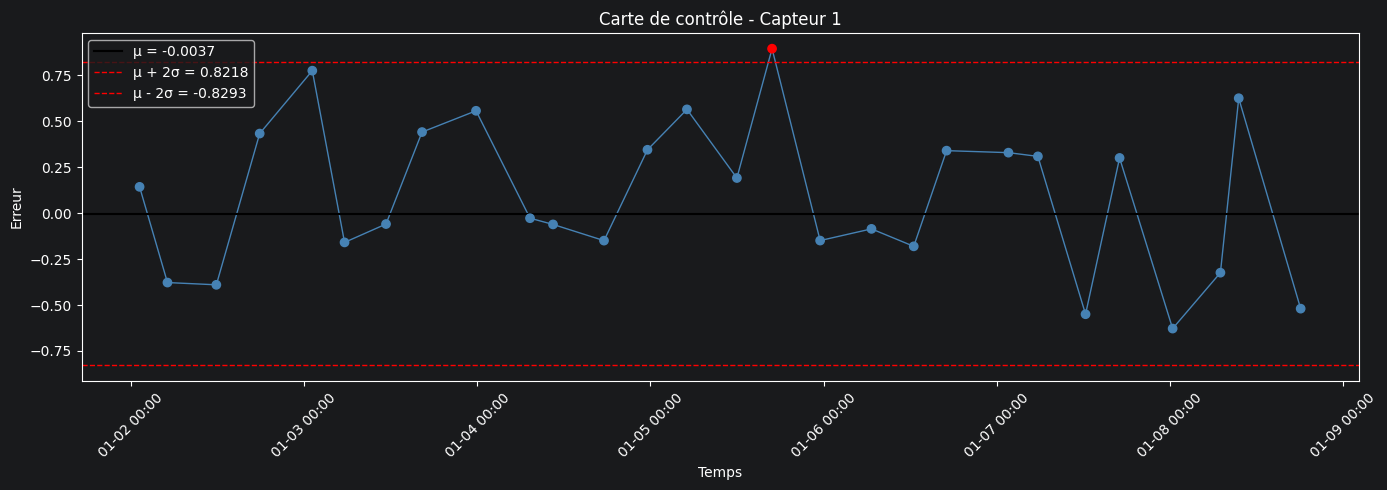

In [1]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# 1) Connexion à la base

conn = psycopg.connect(
    host="iutinfo-sgbd.uphf.fr",
    dbname="capteurs",
    user="iutinfo525",
    password="pXo04pDX"
)


# 2) Récupérer les erreurs (fenêtre 8 jours)


SENSOR_ID = 1

query_points = """
    WITH errors AS (
        SELECT
            cm.controltimestamp,
            cm.controlvalue - sm.sensorvalue AS error
        FROM controlmeasurement cm
        JOIN sensormeasurement sm
            ON sm.sensorid = cm.sensorid
           AND sm.timestamp = cm.sensortimestamp
        WHERE cm.sensorid = %s
    )
    SELECT controltimestamp, error
    FROM errors
    WHERE controltimestamp BETWEEN '2023-01-02' AND '2023-01-09'
    ORDER BY controltimestamp;
"""

with conn.cursor() as cur:
    cur.execute(query_points, (SENSOR_ID,))
    rows = cur.fetchall()

timestamps = [r[0] for r in rows]
errors = [r[1] for r in rows]

print("Nombre de points :", len(errors))


# 2a) Calculer µ et σ sur TOUTES les erreurs du capteur 1


query_stats = """
    WITH errors AS (
        SELECT
            cm.controltimestamp,
            cm.controlvalue - sm.sensorvalue AS error
        FROM controlmeasurement cm
        JOIN sensormeasurement sm
            ON sm.sensorid = cm.sensorid
           AND sm.timestamp = cm.sensortimestamp
        WHERE cm.sensorid = %s
    )
    SELECT
        AVG(error)    AS mu,
        STDDEV(error) AS sigma
    FROM errors;
"""

with conn.cursor() as cur:
    cur.execute(query_stats, (SENSOR_ID,))
    mu, sigma = cur.fetchone()

print("mu   =", mu)
print("sigma=", sigma)


# 3) Tracer la carte de contrôle
fig, ax = plt.subplots(figsize=(14, 5))

colors = [
    "red" if (e < mu - 2*sigma or e > mu + 2*sigma) else "steelblue"
    for e in errors
]

ax.plot(timestamps, errors, color="steelblue", linewidth=1)
ax.scatter(timestamps, errors, color=colors, zorder=5)

ax.axhline(mu,           color="black", linestyle="-",  linewidth=1.5, label=f"µ = {mu:.4f}")
ax.axhline(mu + 2*sigma, color="red",   linestyle="--", linewidth=1,   label=f"µ + 2σ = {mu+2*sigma:.4f}")
ax.axhline(mu - 2*sigma, color="red",   linestyle="--", linewidth=1,   label=f"µ - 2σ = {mu-2*sigma:.4f}")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.xticks(rotation=45)

ax.set_title(f"Carte de contrôle - Capteur {SENSOR_ID}")
ax.set_xlabel("Temps")
ax.set_ylabel("Erreur")
ax.legend()
plt.tight_layout()
plt.show()